In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from embeddings import InputEmbedding
import torch
embedding = InputEmbedding(100, 10)
embedding(torch.arange(2).reshape(1, -1)).shape # (1 seq, 2 words, 10 elements per embedding of the word)

torch.Size([1, 2, 10])

# positional encoding scratchpad

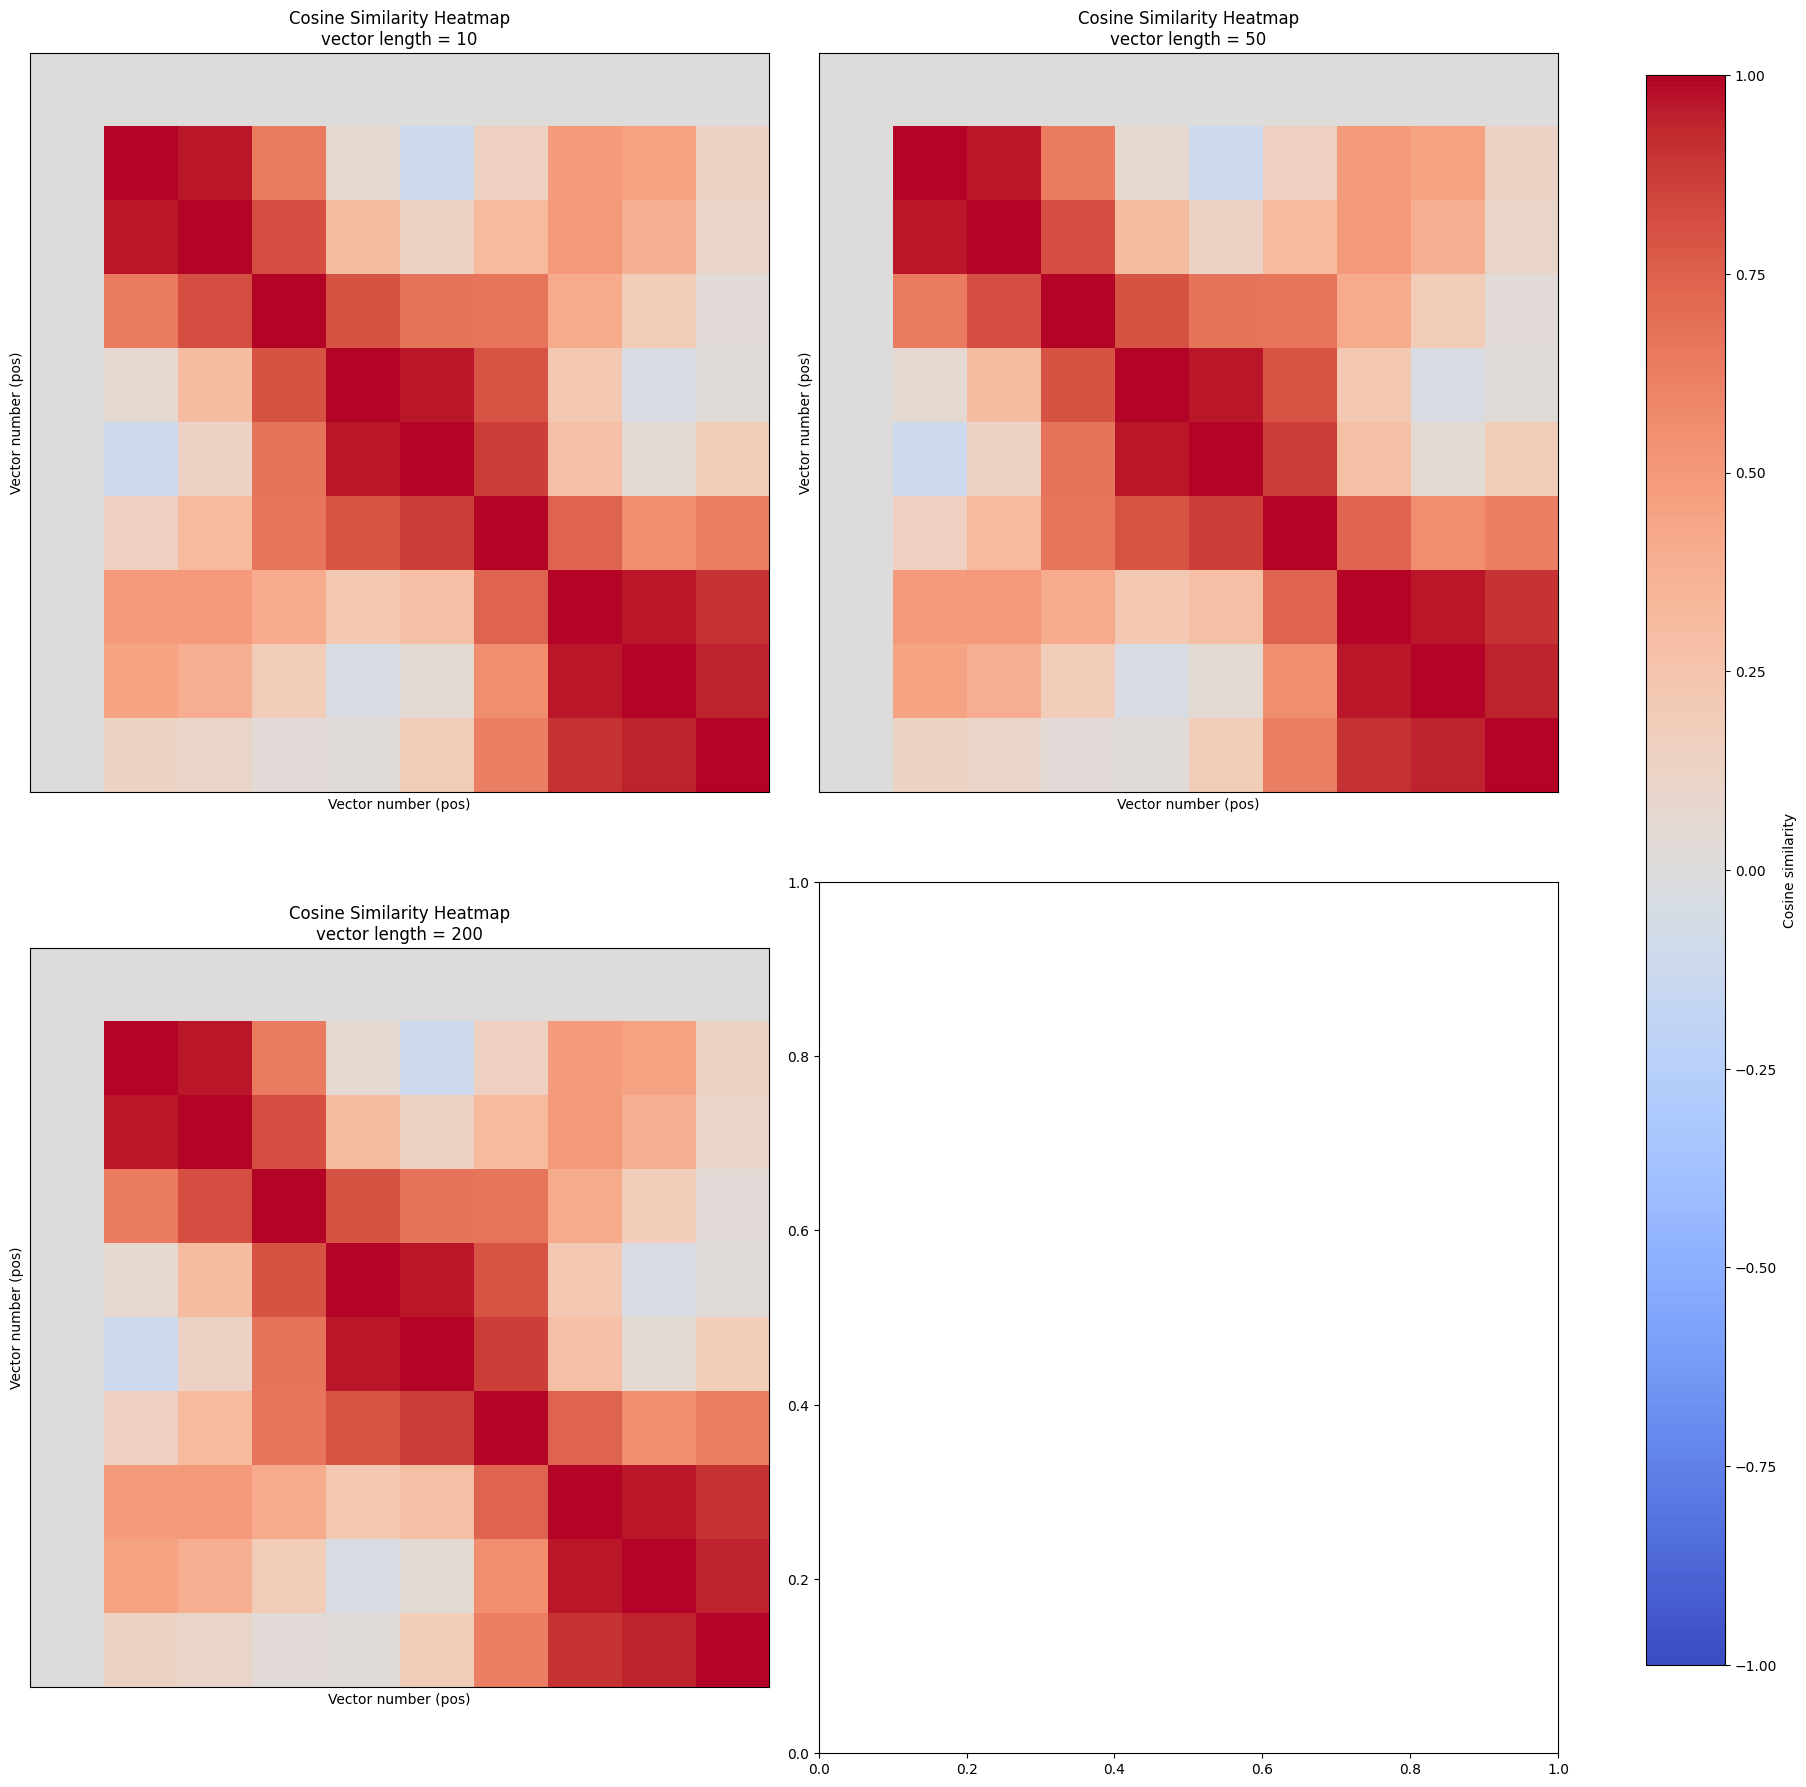

In [4]:
# Reuse existing np/plt imports from the notebook

lengths = [10, 50, 200]
positions = np.arange(10)

fig, axes = plt.subplots(2, 2, figsize=(18, 18), constrained_layout=True)

for ax, dim in zip(axes.flatten(), lengths):
    indices = np.arange(dim)
    vectors = np.sin(positions[:, None] / (2.0 ** indices)[None, :])

    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-12)

    cos_sim = (vectors @ vectors.T) / (norms * norms.T)
    cos_sim = np.clip(cos_sim, -1.0, 1.0)

    im = ax.imshow(cos_sim, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(f"Cosine Similarity Heatmap\nvector length = {dim}")
    ax.set_xlabel("Vector number (pos)")
    ax.set_ylabel("Vector number (pos)")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes, shrink=0.9, label="Cosine similarity")
plt.show()


In [5]:
# test the positional encoding module
from positional_encodings import BinaryPositionalEncoding, SinusoidalPositionalEncoding



In [6]:
# basic positional encoding smoke tests
import torch
from positional_encodings import BinaryPositionalEncoding, SinusoidalPositionalEncoding

x = torch.zeros(2, 5, 8, requires_grad=True)

sin_mod = SinusoidalPositionalEncoding(8)
sin_out = sin_mod(x)
assert sin_out.shape == (2, 5, 8)
assert sin_out.requires_grad is True
assert not torch.allclose(sin_out[:, 0, :], sin_out[:, 1, :])
assert not torch.allclose(sin_out[:, 0, :], sin_out[:, 4, :])

binary_mod = BinaryPositionalEncoding(8)
binary_out = binary_mod(x)
assert binary_out.shape == (2, 5, 8)
assert binary_out.requires_grad is True
assert not torch.allclose(binary_out[:, 0, :], binary_out[:, 1, :])
assert not torch.allclose(binary_out[:, 0, :], binary_out[:, 4, :])

expected = torch.tensor([
    [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
    [ 1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
    [-1.0,  1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
    [ 1.0,  1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
    [-1.0, -1.0,  1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
], dtype=torch.float32)
assert torch.allclose(binary_out[0], expected)

print('PASS: positional encodings are differentiable and position-dependent.')


PASS: positional encodings are differentiable and position-dependent.


In [7]:
# basic layer normalization smoke test
import torch
from normalization import LayerNormalization

x = torch.randn(4, 3, 64, dtype=torch.float32)
ln = LayerNormalization(epsilon=1e-5)
y = ln(x)

mean = y.mean(dim=-1, keepdim=True)
std = y.std(dim=-1, keepdim=True)

assert y.shape == x.shape
assert torch.allclose(mean, torch.zeros_like(mean), atol=1e-4)
assert torch.allclose(std, torch.ones_like(std), atol=1e-4)

print('PASS: layer normalization produces zero-mean, unit-variance outputs along the last dimension.')


PASS: layer normalization produces zero-mean, unit-variance outputs along the last dimension.


In [8]:
# quick feedforward training smoke test
import torch
from torch import nn
from ffn import FeedForwardBlock
import time

torch.manual_seed(time.time())

x = torch.randn(800, 5)
y = 2*x-5

model = FeedForwardBlock(5)
opt = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

for step in range(100000):
    opt.zero_grad()
    pred = model(x)
    loss = loss_fn(pred, y)
    loss.backward()
    opt.step()
    if loss < 1e-8:
        break

final_avg_loss = loss_fn(model(x[2:3]), y[2:3]).item()
print(f'final_loss={final_avg_loss:.8f}, steps={step+1}')
assert final_avg_loss < 1e-6


final_loss=0.00000000, steps=4855


PASS  R2=0.9999  argmax_acc=1.0000


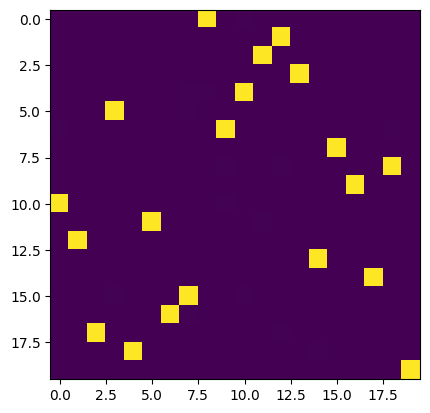

In [9]:
# learnable retrieval attention smoke test
import torch
from torch import nn
from torch.nn import functional as F
from attention import ScaledDotProductAttention

torch.manual_seed(0)

B, T, d_v, d_k = 3000, 20, 1, 8
d_model = d_v + 2 * T          # payload | one-hot absolute position | one-hot pointer

# Each row gets its own permutation, so the routing pattern can't be memorized.
payload = torch.randn(B, T, d_v)
tpos    = torch.stack([torch.randperm(T) for _ in range(B)])   # tpos[b, i] = where i must look
eye     = torch.eye(T)

x = torch.cat([payload,              # what each position carries
               eye.expand(B, T, T),  # KEY field:   "I am position j"
               eye[tpos]], dim=-1)   # QUERY field: "I want position tpos[i]"

target = payload.gather(1, tpos.unsqueeze(-1).expand(B, T, d_v))

attn = ScaledDotProductAttention(d_k=d_k, d_v=d_v, d_model=d_model)
opt  = torch.optim.Adam(attn.parameters(), lr=3e-3)

for _ in range(4000):
    idx = torch.randint(0, B, (256,))
    opt.zero_grad()
    out = attn(x[idx])
    F.mse_loss(out, target[idx]).backward()
    opt.step()

with torch.no_grad():
    A, out = attn(x, True)
    r2   = 1 - F.mse_loss(out, target).item() / target.var(unbiased=False).item()
    acc  = (A.argmax(-1) == tpos).float().mean().item()
    rows = A.sum(-1)

assert out.shape == (B, T, d_v),                    f"shape {tuple(out.shape)}"
assert torch.allclose(rows, torch.ones_like(rows), atol=1e-4), \
       f"attention rows sum to {rows.min():.4f}..{rows.max():.4f}, not 1 — softmax is on the wrong axis"
assert r2 > 0.99,  f"R2={r2:.4f} — not retrieving"
assert acc > 0.99, f"argmax_acc={acc:.4f} — hedging across positions"
print(f"PASS  R2={r2:.4f}  argmax_acc={acc:.4f}")
plt.imshow(A[2].detach().numpy(), cmap='viridis')

In [10]:
%load_ext autoreload
%autoreload 2

PASS  R2=1.0000


TypeError: Invalid shape (3000, 20, 20) for image data

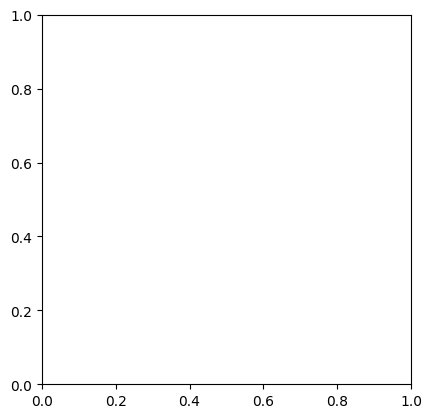

In [ ]:
import optimized_mha
import torch.nn.functional as F

B, T, d_v, d_k = 3000, 20, 1, 8
d_model = d_v + 2 * T
tpos    = torch.stack([torch.randperm(T) for _ in range(B)])   # tpos[b, i] = where i must look

attn = optimized_mha.OptimizedMultiHeadAttention(n_heads = 4, d_k=d_k, d_v=d_v, d_model=d_model, d_out=d_v)
opt  = torch.optim.Adam(attn.parameters(), lr=3e-3)

for _ in range(4000):
    idx = torch.randint(0, B, (256,))
    opt.zero_grad()
    out = attn(x[idx])
    F.mse_loss(out, target[idx]).backward()
    opt.step()

with torch.no_grad():
    A, out = attn(x, True)
    r2   = 1 - F.mse_loss(out, target).item() / target.var(unbiased=False).item()

assert out.shape == (B, T, d_v), f"shape {tuple(out.shape)}"
assert r2 > 0.99,  f"R2={r2:.4f} — not retrieving"
print(f"PASS  R2={r2:.4f}")

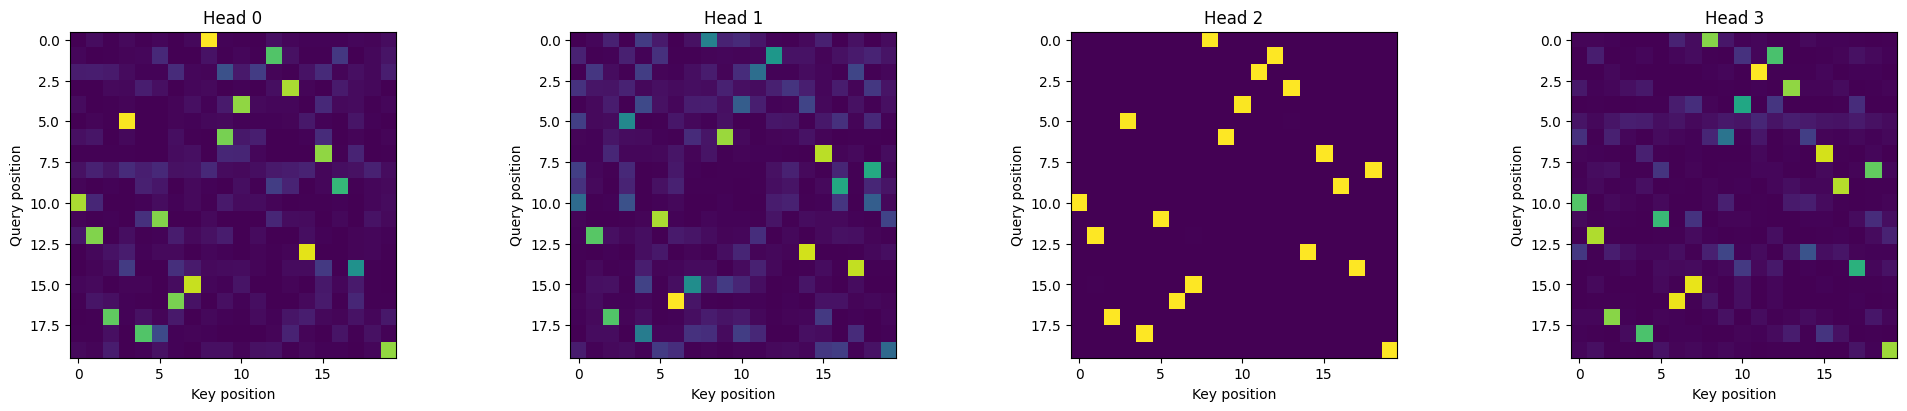

In [21]:
fig, axes = plt.subplots(1, len(A), figsize=(20, 4), constrained_layout=True)

for ax, (i, head) in zip(axes, enumerate(A)):
    ax.imshow(head[2].detach().numpy(), cmap='viridis')
    ax.set_title(f"Head {i}")
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")

plt.show()